In [ ]:
import pandas as pd # Untuk membaca dan mengolah data berbentuk tabel (DataFrame)
import numpy as np # Operasi Matematika dan Komputasi Angka
import os # Untuk manajemen direktori/folder
from sklearn.preprocessing import MinMaxScaler # Skalasi Data (Normalisasi)

# Fungsi membersihkan mata uang di dataset (menghapus titik, ubah koma ke titik)
def clean_currency(x):
    if isinstance(x, str):
        return x.replace('.', '').replace(',', '.')
    return x

# Path dataset (Silakan sesuaikan base_path ini dengan direktori komputer Anda)
base_path = r'C:\Users\evald\OneDrive\Documents\Skripsi\Dataset'

file_names = [
    "Data Historis KLBF.csv",
    "Data Historis PEHA.csv",
    "Data Historis SIDO.csv",
    "Data Historis SOHO.csv"
]

# Dictionary untuk memetakan singkatan kode saham ke nama perusahaan lengkap sesuai dataset
stock_mapping = {
    "KLBF": "Kalbe Farma Tbk PT (KLBF)",
    "PEHA": "Phapros Tbk PT (PEHA)",
    "SIDO": "Sido Muncul Tbk PT (SIDO)",
    "SOHO": "Soho Global Health Tbk Pt (SOHO)"
}

processed_dfs = {}

print("="*60)
print("📥 MENAMPILKAN DATASET SEBELUM PREPROCESSING")
print("="*60)

for file in file_names:
    full_path = os.path.join(base_path, file)
    
    if not os.path.exists(full_path):
        print(f"⚠️ File TIDAK ditemukan: {full_path}")
        continue

    # Membaca Data Mentah dengan separator ';' sesuai format file .csv Anda
    df_raw = pd.read_csv(full_path, sep=';')

    print(f"\n📊 Dataset RAW: {file}")
    print(f"Shape Awal: {df_raw.shape}")
    
    # Pemrosesan Data
    df = df_raw.copy()

    # Membersihkan nama kolom (menghapus spasi atau karakter aneh BOM)
    df.columns = [c.replace('\ufeff', '').strip() for c in df.columns]
    
    # Bersihkan nilai string mata uang dan ubah tipe datanya menjadi float
    df['Terakhir'] = df['Terakhir'].apply(clean_currency).astype(float)
    
    # Format Kolom Tanggal agar dikenali sebagai objek datetime
    df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True)
    
    # Urutkan data berdasarkan tanggal dari masa lampau hingga yang paling baru (Wajib untuk Time Series)
    df = df.sort_values('Tanggal').reset_index(drop=True)
    
    # === TAMBAHAN: HITUNG LOG RETURN ===
    # Rumus: ln(Harga_Hari_Ini / Harga_Kemarin)
    df['Log_Return'] = np.log(df['Terakhir'] / df['Terakhir'].shift(1))
    
    # Drop baris pertama karena menghasilkan nilai NaN akibat tidak punya data hari sebelumnya
    df = df.dropna(subset=['Log_Return']).reset_index(drop=True)
    
    # === PENYESUAIAN UNIVARIATE: Menggunakan fitur 'Log_Return' sebagai input ===
    feature_cols = ['Log_Return']
    
    # Mengambil nilai array dari kolom 'Log_Return' dan dibentuk menjadi matriks 2D [Jumlah_Baris, 1]
    features = df[feature_cols].values 
    
    # Lakukan fit dan transform menggunakan MinMaxScaler khusus untuk Log Return per emiten
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(features)
    
    # Mengambil inisial (KLBF, PEHA, SIDO, SOHO) dari nama file asli
    stock_code = file.replace('Data Historis ', '').replace('.csv', '')
    
    # Mengubah nama stock berdasarkan nama lengkap perusahaan sesuai mapping dictionary
    full_stock_name = stock_mapping.get(stock_code, stock_code)
    
    # Menyimpan hasil akhir ke dalam dictionary processed_dfs
    processed_dfs[full_stock_name] = {
        # Menyimpan kolom Tanggal, Terakhir (Asli), dan Log_Return
        'df': df[['Tanggal', 'Terakhir', 'Log_Return']].reset_index(drop=True), 
        'scaled': scaled_features,                                  # Matriks normalisasi Log Return berdimensi [N, 1]
        'scaler': scaler                                            # Objek scaler disimpan untuk proses denormalisasi nanti
    }
    
    print(f"Shape Setelah Log Return & Drop NaN: {df.shape}")
    print(f"✅ Preprocessing {full_stock_name} selesai.")
    print("-"*50)

# Hasil Setelah Preprocessing Univariate Log Return
print("\n" + "="*60)
print("📊 HASIL SETELAH PREPROCESSING (1 INPUT: UNIVARIATE 'LOG_RETURN')")
print("="*60)

for stock, content in processed_dfs.items():
    print(f"\n📈 Dataset: {stock}")
    print(f"Shape Target Scaled: {content['scaled'].shape}") # Akan menghasilkan (jumlah_baris, 1)
    
    # Menampilkan Hasil DataFrame bersih teratas (Terlihat kolom Log_Return sudah terisi)
    print(content['df'].head(5))

📥 MENAMPILKAN DATASET SEBELUM PREPROCESSING

📊 Dataset RAW: Data Historis KLBF.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Kalbe Farma Tbk PT (KLBF) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis PEHA.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Phapros Tbk PT (PEHA) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis SIDO.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Sido Muncul Tbk PT (SIDO) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis SOHO.csv
Shape Awal: (651, 7)
Shape Setelah Log Return & Drop NaN: (650, 8)
✅ Preprocessing Soho Global Health Tbk Pt (SOHO) selesai.
--------------------------------------------------

📊 HASIL SETELAH PREPROCESSING (1 INPUT: UNIVARIATE 'LOG_RETURN')

📈 Dataset: Kalbe Farma Tbk PT (KLBF)
Shape Target Scal


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Kalbe Farma Tbk PT (KLBF)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)


Training model Kalbe Farma Tbk PT (KLBF) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0626 - mae: 0.3292 - val_loss: 0.0481 - val_mae: 0.2604
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0155 - mae: 0.1411 - val_loss: 0.0207 - val_mae: 0.1645
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0070 - mae: 0.0901 - val_loss: 0.0192 - val_mae: 0.1584
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0061 - mae: 0.0837 - val_loss: 0.0182 - val_mae: 0.1555
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0059 - mae: 0.0816 - val_loss: 0.0183 - val_mae: 0.1551
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0058 - mae: 0.0811 - val_loss: 0.0182 - val_mae: 0.1550
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0058 - mae: 0.0811 - val_loss: 0.0182 - val_mae: 0.1550
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0058 - mae: 0.0810 - val_loss: 0.0182 - val_mae: 0.1550
E

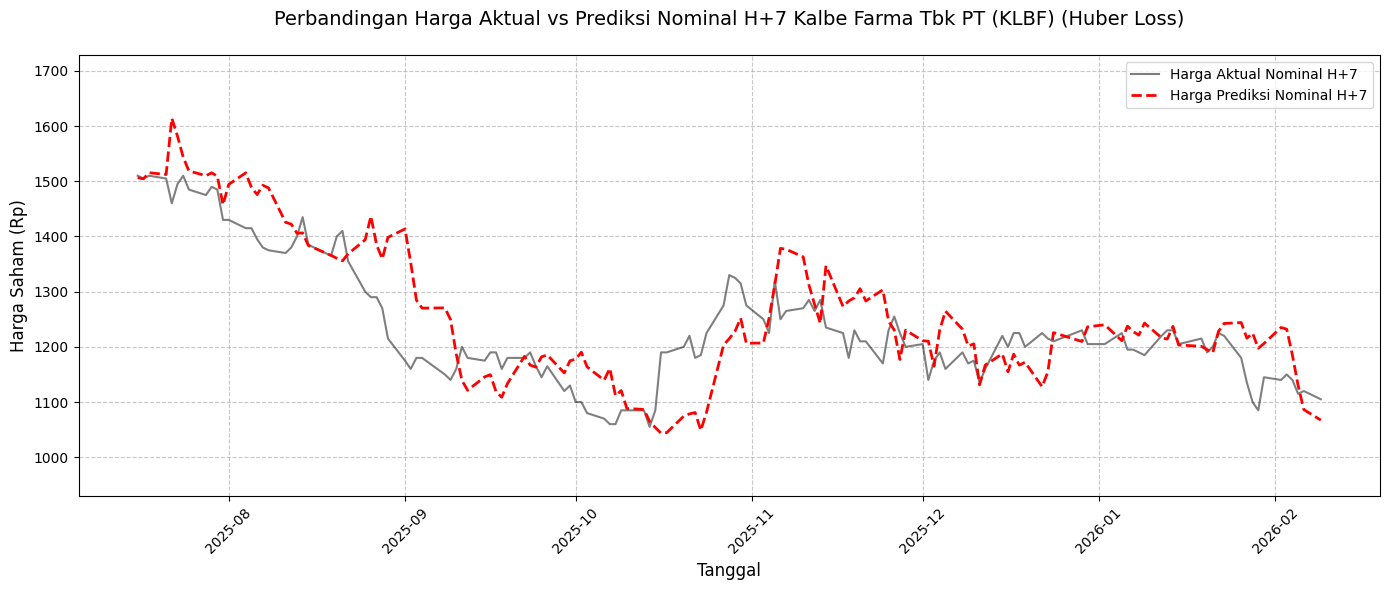

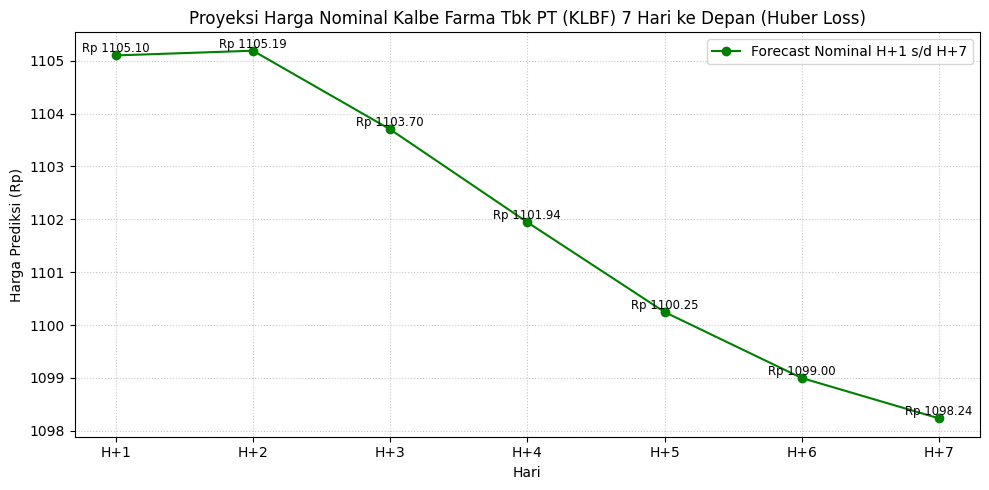

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# FUNGSI PENDUKUNG (DENORMALISASI)
# =====================================================================

# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T

# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# =====================================================================
# PEMBUATAN MODEL (Tanpa Attention Mechanism)
# =====================================================================

def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(layers):
        # Jika layer terakhir, return_sequences harus False karena akan masuk ke Dense layer
        is_last_layer = (i == layers - 1)
        x = LSTM(
            units,
            return_sequences=not is_last_layer
        )(x)

    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="huber",  # Menggunakan Huber loss
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER & PERSIAPAN DATA
# =====================================================================
stock = "Kalbe Farma Tbk PT (KLBF)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Asumsi `processed_dfs` sudah didefinisikan sebelumnya di environment Anda
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# =====================================================================
# PELATIHAN MODEL
# =====================================================================

model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# =====================================================================
# PREDIKSI & EVALUASI
# =====================================================================

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)

# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# =====================================================================
# VISUALISASI & EXPORT
# =====================================================================

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Phapros Tbk PT (PEHA)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)


Training model Phapros Tbk PT (PEHA) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0724 - mae: 0.3666 - val_loss: 0.0452 - val_mae: 0.2778
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0223 - mae: 0.1780 - val_loss: 0.0097 - val_mae: 0.1043
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0048 - mae: 0.0656 - val_loss: 0.0050 - val_mae: 0.0670
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035 - mae: 0.0500 - val_loss: 0.0037 - val_mae: 0.0502
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0031 - mae: 0.0414 - val_loss: 0.0036 - val_mae: 0.0487
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0030 - mae: 0.0393 - val_loss: 0.0036 - val_mae: 0.0480
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0030 - mae: 0.0387 - val_loss: 0.0036 - val_mae: 0.0476
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0030 - mae: 0.0385 - val_loss: 0.0036 - val_mae: 0.0478
Epoch

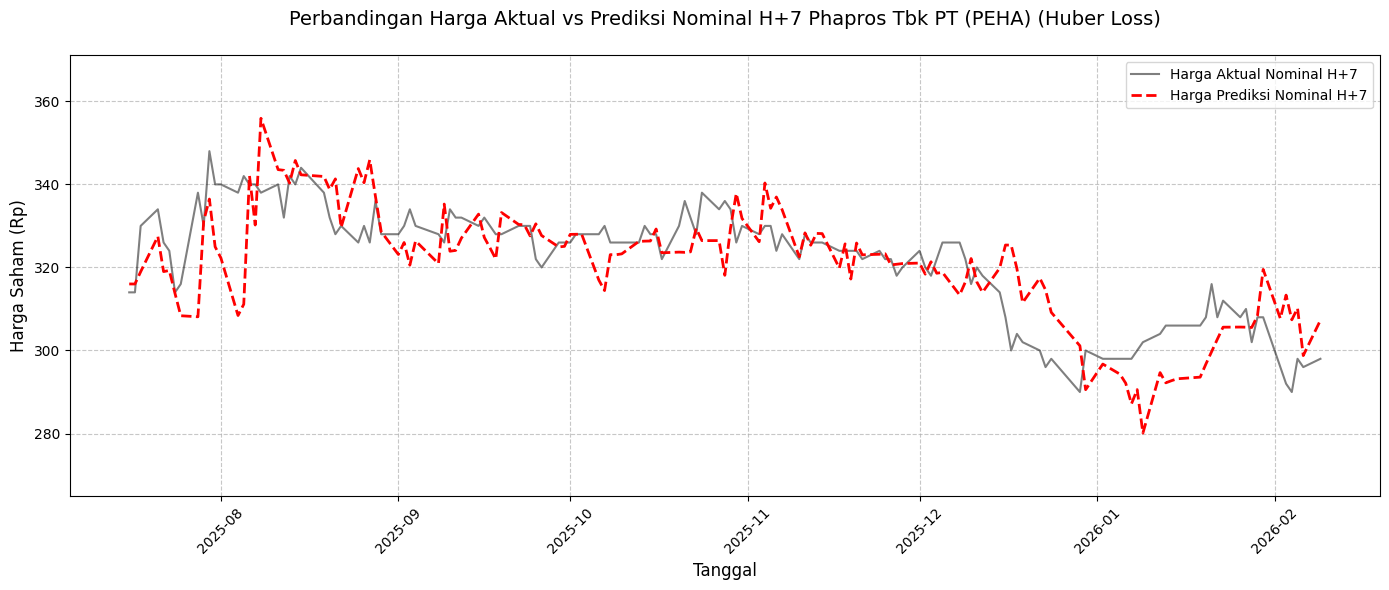

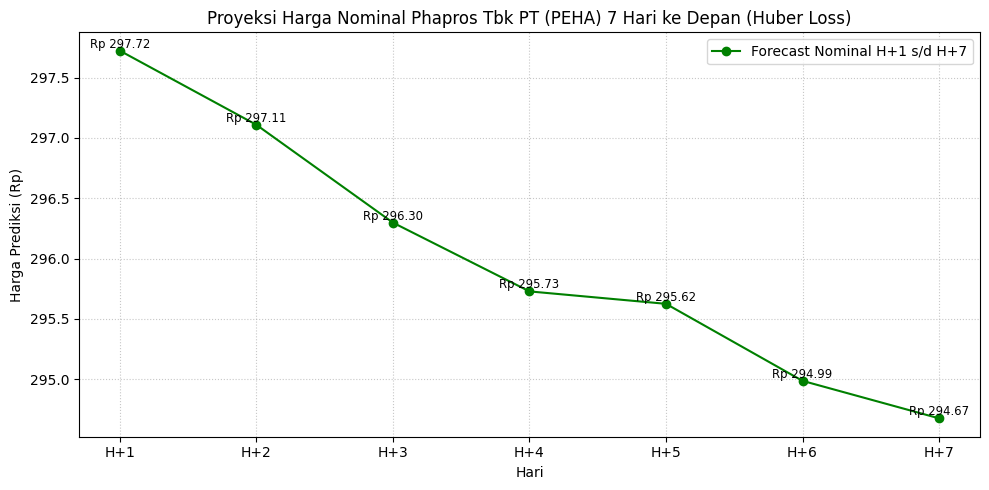

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# FUNGSI PENDUKUNG (DENORMALISASI)
# =====================================================================

# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T

# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# =====================================================================
# PEMBUATAN MODEL (Tanpa Attention Mechanism)
# =====================================================================

def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(layers):
        # Jika layer terakhir, return_sequences harus False karena akan masuk ke Dense layer
        is_last_layer = (i == layers - 1)
        x = LSTM(
            units,
            return_sequences=not is_last_layer
        )(x)

    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="huber",  # Menggunakan Huber loss
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER & PERSIAPAN DATA
# =====================================================================
stock = "Phapros Tbk PT (PEHA)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Asumsi `processed_dfs` sudah didefinisikan sebelumnya di environment Anda
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# =====================================================================
# PELATIHAN MODEL
# =====================================================================

model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# =====================================================================
# PREDIKSI & EVALUASI
# =====================================================================

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)

# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# =====================================================================
# VISUALISASI & EXPORT
# =====================================================================

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Sido Muncul Tbk PT (SIDO)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)


Training model Sido Muncul Tbk PT (SIDO) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.1486 - mae: 0.5271 - val_loss: 0.1052 - val_mae: 0.4372
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0625 - mae: 0.3133 - val_loss: 0.0194 - val_mae: 0.1596
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0127 - mae: 0.1246 - val_loss: 0.0072 - val_mae: 0.0890
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0062 - mae: 0.0825 - val_loss: 0.0067 - val_mae: 0.0856
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0055 - mae: 0.0756 - val_loss: 0.0060 - val_mae: 0.0790
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0051 - mae: 0.0723 - val_loss: 0.0059 - val_mae: 0.0773
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0051 - mae: 0.0719 - val_loss: 0.0059 - val_mae: 0.0770
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0051 - mae: 0.0716 - val_loss: 0.0059 - val_mae: 0.0770
E

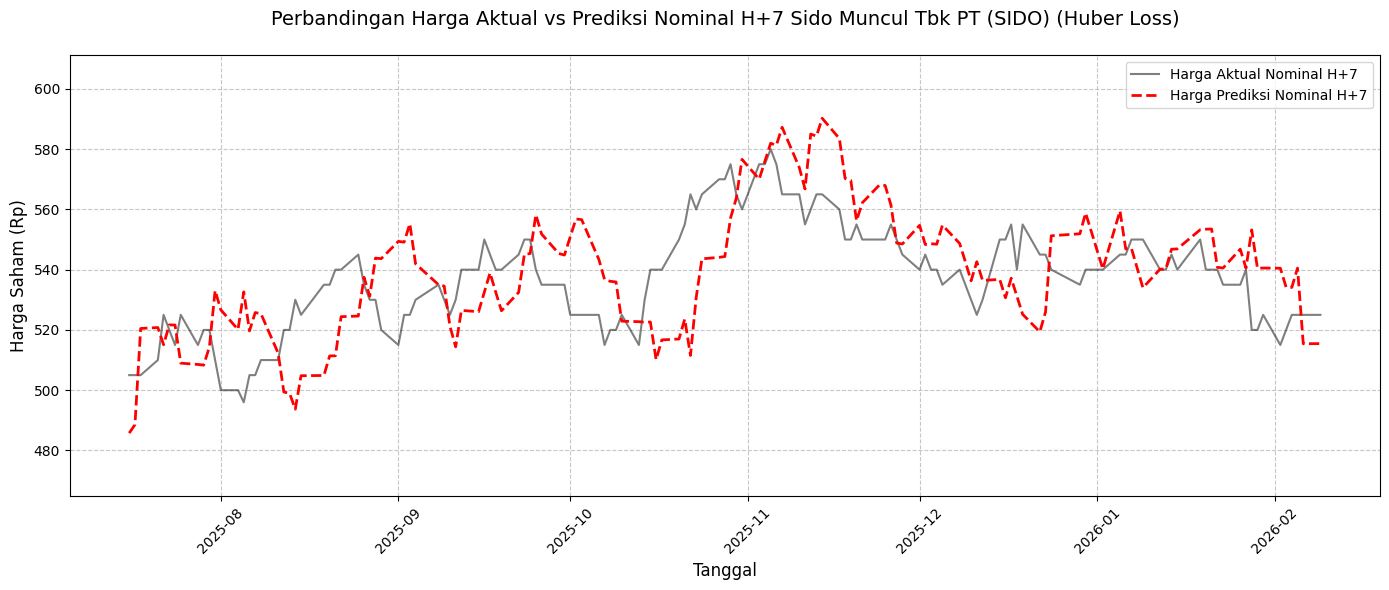

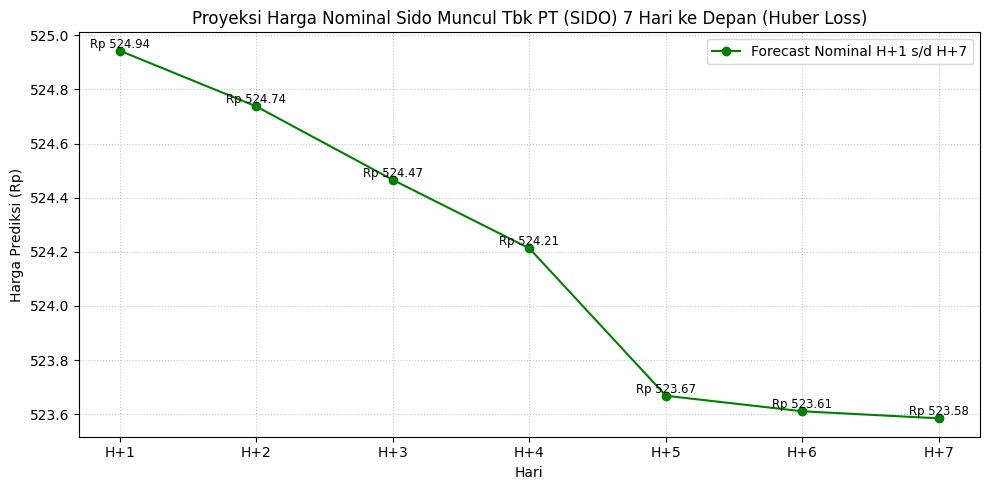

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# FUNGSI PENDUKUNG (DENORMALISASI)
# =====================================================================

# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T

# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# =====================================================================
# PEMBUATAN MODEL (Tanpa Attention Mechanism)
# =====================================================================

def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(layers):
        # Jika layer terakhir, return_sequences harus False karena akan masuk ke Dense layer
        is_last_layer = (i == layers - 1)
        x = LSTM(
            units,
            return_sequences=not is_last_layer
        )(x)

    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="huber",  # Menggunakan Huber loss
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER & PERSIAPAN DATA
# =====================================================================
stock = "Sido Muncul Tbk PT (SIDO)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Asumsi `processed_dfs` sudah didefinisikan sebelumnya di environment Anda
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# =====================================================================
# PELATIHAN MODEL
# =====================================================================

model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# =====================================================================
# PREDIKSI & EVALUASI
# =====================================================================

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)

# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# =====================================================================
# VISUALISASI & EXPORT
# =====================================================================

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (490, 30, 1)
Test  : (124, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 05 January 2023 s/d 14 July 2025
Data Uji (Test)    : 15 July 2025 s/d 09 February 2026

SUMMARY MODEL Soho Global Health Tbk Pt (SOHO)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)


Training model Soho Global Health Tbk Pt (SOHO) dengan Huber Loss...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0914 - mae: 0.4164 - val_loss: 0.0641 - val_mae: 0.3426
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0437 - mae: 0.2754 - val_loss: 0.0201 - val_mae: 0.1773
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0100 - mae: 0.1115 - val_loss: 0.0043 - val_mae: 0.0665
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0026 - mae: 0.0467 - val_loss: 0.0037 - val_mae: 0.0558
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0023 - mae: 0.0416 - val_loss: 0.0034 - val_mae: 0.0512
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - mae: 0.0332 - val_loss: 0.0033 - val_mae: 0.0497
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0019 - mae: 0.0324 - val_loss: 0.0033 - val_mae: 0.0493
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0019 - mae: 0.0313 - val_loss: 0.0033 - val_mae: 0

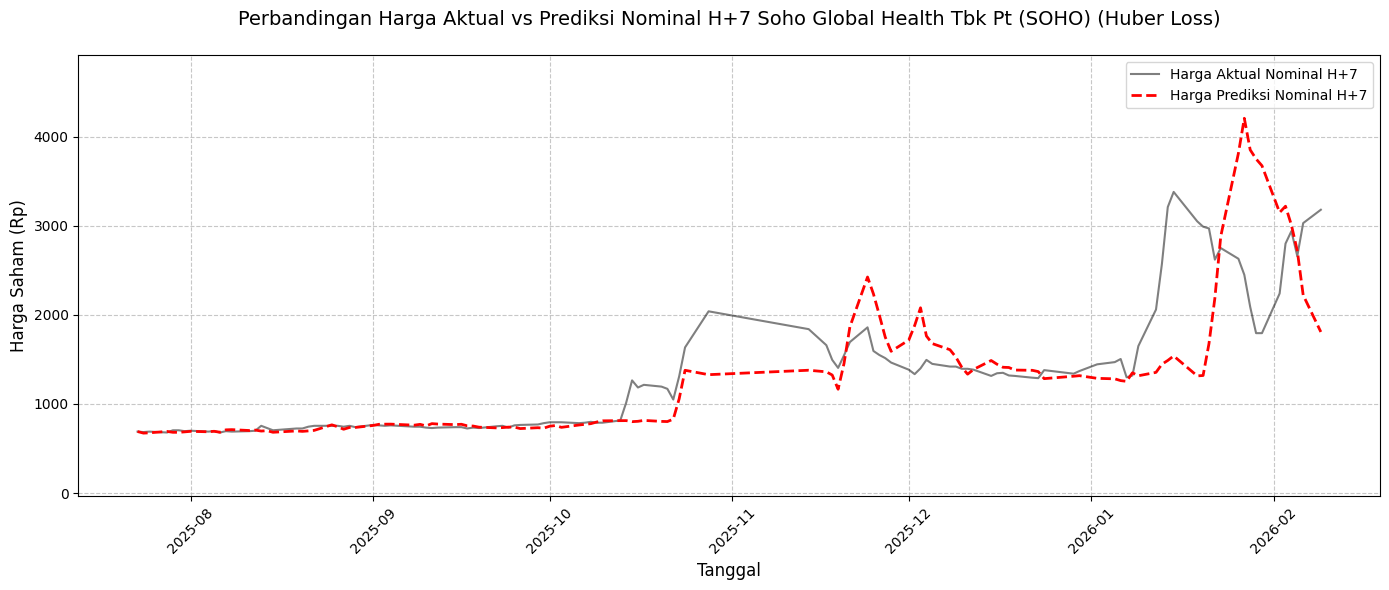

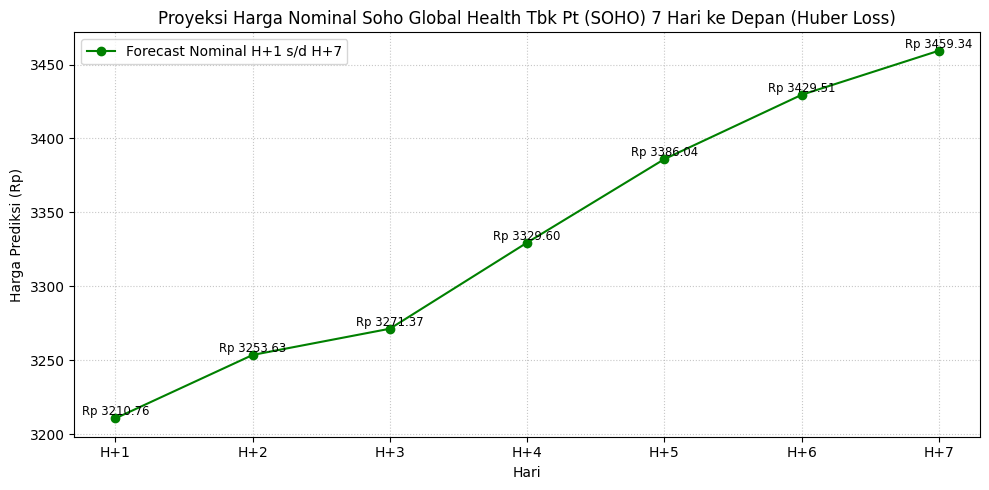

In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# FUNGSI PENDUKUNG (DENORMALISASI)
# =====================================================================

# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T

# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# =====================================================================
# PEMBUATAN MODEL (Tanpa Attention Mechanism)
# =====================================================================

def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(layers):
        # Jika layer terakhir, return_sequences harus False karena akan masuk ke Dense layer
        is_last_layer = (i == layers - 1)
        x = LSTM(
            units,
            return_sequences=not is_last_layer
        )(x)

    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="huber",  # Menggunakan Huber loss
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER & PERSIAPAN DATA
# =====================================================================
stock = "Soho Global Health Tbk Pt (SOHO)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Asumsi `processed_dfs` sudah didefinisikan sebelumnya di environment Anda
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# =====================================================================
# PELATIHAN MODEL
# =====================================================================

model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# =====================================================================
# PREDIKSI & EVALUASI
# =====================================================================

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)

# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# =====================================================================
# VISUALISASI & EXPORT
# =====================================================================

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()